In [1]:
import os
import sys

sys.stderr = open(os.devnull, "w")

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
import pytz
from datetime import timedelta
from dateutil.relativedelta import relativedelta
from sklearn.utils import resample
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

warnings.filterwarnings('ignore', category=FutureWarning)

np.random.seed(42)

In [2]:
def calculate_prediction_intervals(y_test, gb_forecast, confidence_level=0.95, n_bootstrap=1000):
    """
    Calculate prediction intervals using bootstrapping.

    Parameters:
    - y_test: pandas.Series, actual test values
    - forecast: pandas.Series, forecasted values
    - confidence_level: float, confidence level for prediction interval (e.g., 0.95 for 95%)
    - n_bootstrap: int, number of bootstrap samples

    Returns:
    - lower_bound: pandas.Series, lower bound of prediction interval
    - upper_bound: pandas.Series, upper bound of prediction interval
    """
    # Step 3: Calculate residuals
    residuals = y_test - gb_forecast

    # Step 4: Bootstrapping
    bootstrap_samples = []
    for _ in range(n_bootstrap):
        sample_residuals = np.random.choice(residuals, size=len(residuals), replace=True)
        bootstrap_forecast = gb_forecast + sample_residuals
        bootstrap_samples.append(bootstrap_forecast)

    # Step 6: Calculate prediction intervals
    lower_percentile = (1 - confidence_level) / 2 * 100
    upper_percentile = (1 + confidence_level) / 2 * 100
    lower_bound = pd.Series(np.percentile(bootstrap_samples, lower_percentile, axis=0), index=y_test.index)
    forecast = pd.Series(np.percentile(bootstrap_samples, 50, axis=0), index=y_test.index)
    upper_bound = pd.Series(np.percentile(bootstrap_samples, upper_percentile, axis=0), index=y_test.index)

    return lower_bound, forecast, upper_bound

In [3]:
def calculate_oot_prediction_intervals(df, X_oot, target_column='price_total_agg', confidence_level=0.95, n_bootstrap=1000):
    """
    Calculate OOT prediction intervals for out-of-time data.

    Parameters:
    - df: pandas.DataFrame, training data containing features and target
    - X_oot: pandas.DataFrame, out-of-time features
    - oot_gb: OOT model
    - target_column: str, name of the target column in df (default: 'price_total_agg')
    - n_bootstrap: int, number of bootstrap samples (default: 1000)
    - confidence_level: float, confidence level for prediction interval (default: 0.95)

    Returns:
    - oot_gb_forecast_lower: pandas.Series, lower bound of prediction interval
    - oot_gb_forecast: pandas.Series, median forecast
    - oot_gb_forecast_upper: pandas.Series, upper bound of prediction interval
    """
    # Calculate percentiles based on confidence level
    lower_percentile = (1 - confidence_level) / 2 * 100
    upper_percentile = (1 + confidence_level) / 2 * 100

    bootstrap_predictions = []
    
    for _ in range(n_bootstrap):
        # Generate bootstrap sample
        df_boot = resample(df).sort_index(ascending=True)
        df_boot.index = df.index
        X_boot = df_boot.drop(columns=[target_column])
        y_boot = df_boot[target_column]
        
        # Train a new model on the bootstrap sample
        gscv = GridSearchCV(GradientBoostingRegressor(random_state=42, n_iter_no_change=3),
                            param_grid={'max_depth': [1, 2, 4, 8, 16],
                                        'subsample': [0.2, 0.4, 0.6, 0.8, 1],
                                        'max_features': ['sqrt', 'log2', None]},
                            scoring='neg_root_mean_squared_error',
                            cv=TimeSeriesSplit(),
                            n_jobs=-1,
                            verbose=1)
        gscv.fit(X_boot, y_boot)
        oot_boot_gb = gscv.best_estimator_
        
        # Generate predictions from the bootstrap model
        bootstrap_pred = oot_boot_gb.predict(X_oot)
        bootstrap_predictions.append(bootstrap_pred)

    # Calculate lower and upper bounds for the prediction intervals
    bootstrap_predictions = np.array(bootstrap_predictions).squeeze()
    oot_gb_forecast_lower = pd.Series(np.percentile(bootstrap_predictions, lower_percentile, axis=0), index=X_oot.index)
    oot_gb_forecast = pd.Series(np.percentile(bootstrap_predictions, 50, axis=0), index=X_oot.index)
    oot_gb_forecast_upper = pd.Series(np.percentile(bootstrap_predictions, upper_percentile, axis=0), index=X_oot.index)

    return oot_gb_forecast_lower, oot_gb_forecast, oot_gb_forecast_upper

In [4]:
sales = pd.read_csv('pedidos-1743765883268.csv', sep=';', encoding='latin1')

In [5]:
df = sales[['account_id', 'sales_channel_id']].value_counts()
df = pd.DataFrame(df).reset_index()

In [6]:
import pandas as pd

In [7]:
pd.to_datetime('2025-03-31 00:00:00')

Timestamp('2025-03-31 00:00:00')

In [8]:
SAO_PAULO_TZ = pytz.timezone('America/Sao_Paulo')
LOOKBACK = 1
SEASONAL_PERIODS = (24, 24*7)
END_DATE = pd.to_datetime(pd.to_datetime(sales['created_date'].max()).strftime("%Y-%m-%d %H:00:00"))
# START_DATE = END_DATE - timedelta(hours=END_DATE.hour)
START_DATE = END_DATE - timedelta(hours=23)
TEST_SIZE = int((END_DATE - START_DATE).seconds / 60**2 + 1)

In [9]:
# OOT_DATE = START_DATE + timedelta(hours=23)

In [10]:
# OOT_PERIODS = int((OOT_DATE - END_DATE).seconds / 60**2 + 1)

In [11]:
# oot_dates = pd.DatetimeIndex([END_DATE+timedelta(hours=h) for h in range(1, OOT_PERIODS)], freq='h')
# df_oot = pd.DataFrame(index=oot_dates)

In [12]:
# df.drop('count', axis=1, inplace=True)
# for account_id in df['account_id'].unique():
#     df = pd.concat([df, pd.DataFrame({'account_id': [account_id], 'sales_channel_id': ['ALL']})], ignore_index=True)

In [13]:
df[df['account_id'] == 'b8c6ac4b-2999-40f4-ad33-17649fb2f0aa']

,account_id,sales_channel_id,count
37,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,1,83032
70,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,17,16118
89,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,4,9423
119,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,2,3614
124,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,13,3320
125,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,14,3253
127,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,6,2964
134,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,5,2237
144,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,19,1791
162,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,15,1217


In [14]:
account_ids = ['f9129295-bb08-4330-b60c-9f0beadda521', '05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6', '9d39683a-47b3-4a18-942d-f1d741a47e8c']

df_filtered = df[df['account_id'].isin(account_ids)]

In [15]:
df_filtered

,account_id,sales_channel_id,count
1,9d39683a-47b3-4a18-942d-f1d741a47e8c,1,2542841
2,05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6,3,1908829
5,05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6,6,876335
7,f9129295-bb08-4330-b60c-9f0beadda521,1,486716
11,f9129295-bb08-4330-b60c-9f0beadda521,2,321190
15,05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6,5,263987
29,f9129295-bb08-4330-b60c-9f0beadda521,10,106300
48,f9129295-bb08-4330-b60c-9f0beadda521,38,47359
51,f9129295-bb08-4330-b60c-9f0beadda521,16,41229
55,f9129295-bb08-4330-b60c-9f0beadda521,18,29153


In [16]:
dbname = 'railway'
username = 'sinatra'
pwd = '781B3XjpeuqE'
hostname = 'monorail.proxy.rlwy.net'
port = 25096

connection = psycopg2.connect(database=dbname, user=username, password=pwd, host=hostname, port=port)
cursor = connection.cursor()

In [17]:
cursor.execute("select distinct account_id, channel from public.forecast where model='GradientBoosting\_%';")

In [18]:
res_forecast = cursor.fetchall()

In [19]:
len(res_forecast)

0

account_id: 9d39683a-47b3-4a18-942d-f1d741a47e8c
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 14471.510
train MAE:  10394.981
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
test RMSE: 15561.913
test MAE:  12008.751


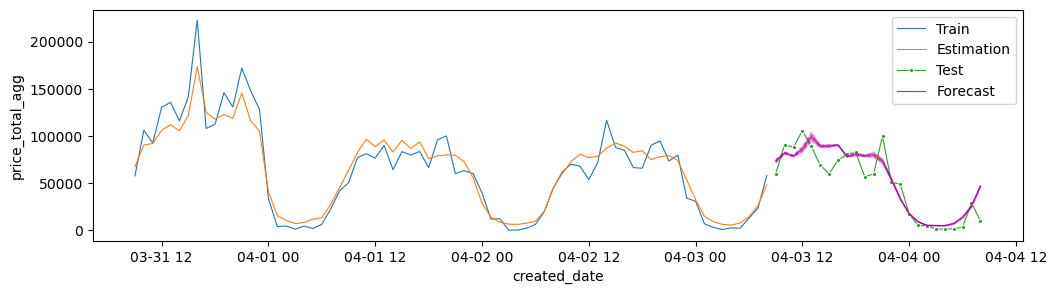

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 4.968
train MAE:  1.715
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
test RMSE: 16.290
test MAE:  11.691


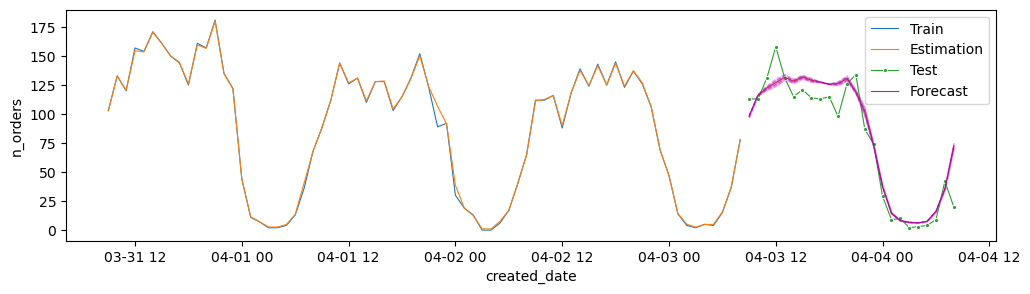

account_id: 05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6
sales_channel_id: 3
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 2608.795
train MAE:  1503.781
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
test RMSE: 6375.536
test MAE:  4764.273


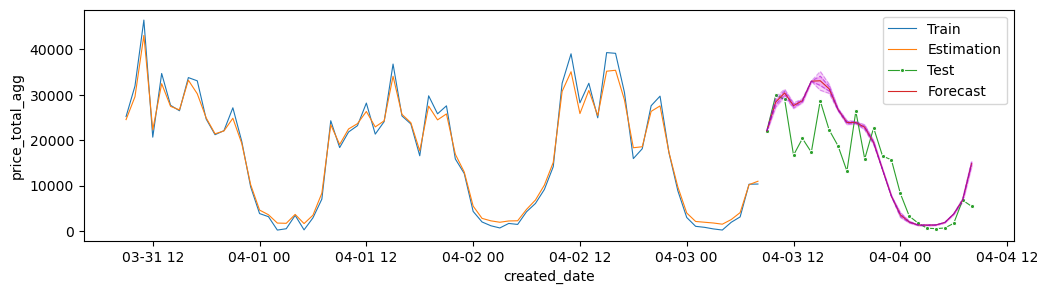

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 3.308
train MAE:  0.827
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
test RMSE: 15.033
test MAE:  10.682


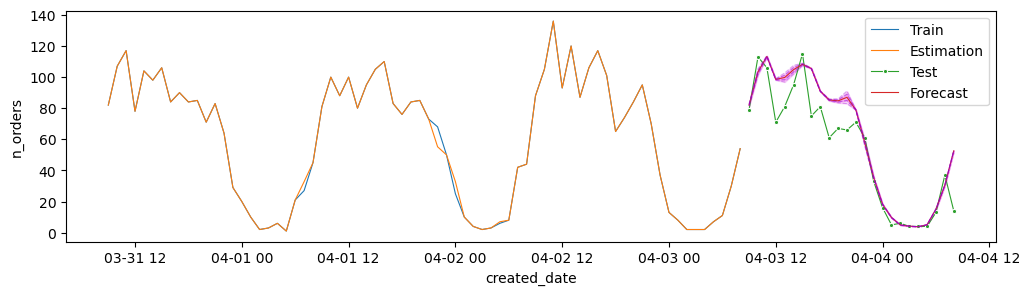

account_id: 05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6
sales_channel_id: 6
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 3000.638
train MAE:  2226.546
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
test RMSE: 3071.049
test MAE:  2334.113


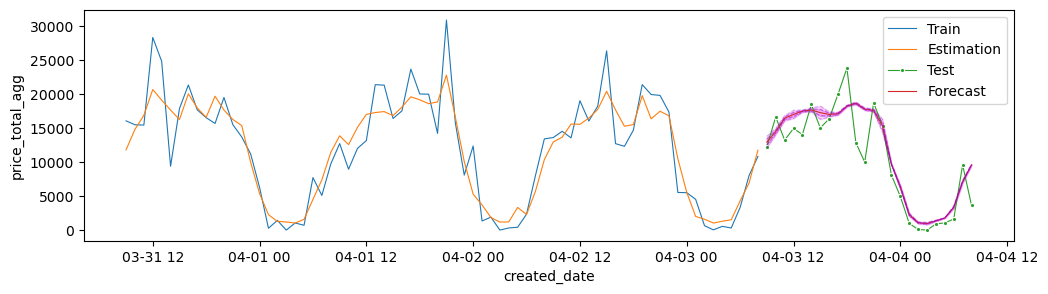

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 6.020
train MAE:  4.562
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
test RMSE: 5.857
test MAE:  3.991


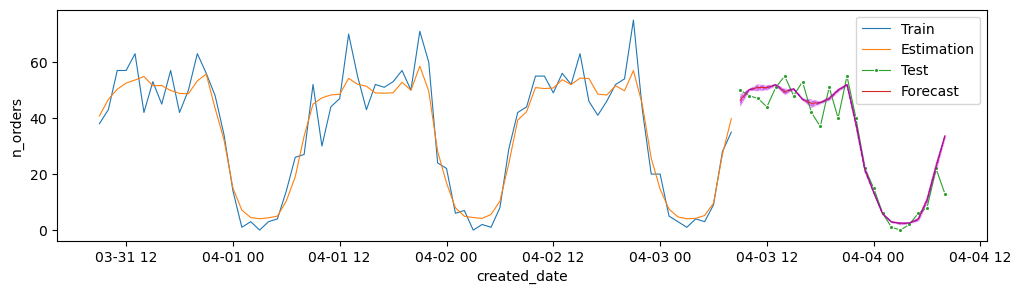

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 48445.262
train MAE:  32909.487
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
test RMSE: 40243.820
test MAE:  28118.839


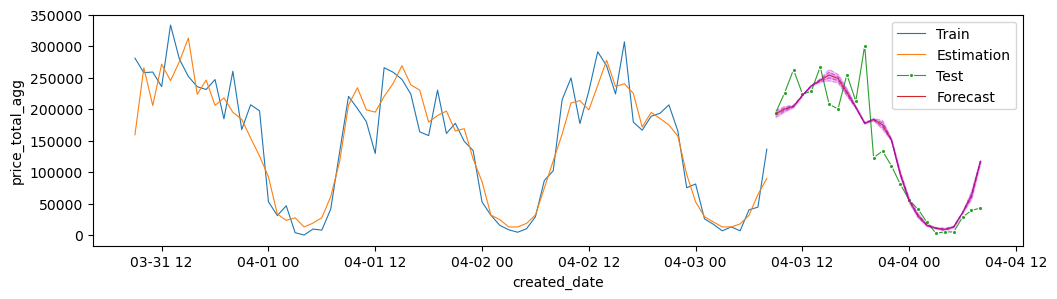

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 7.751
train MAE:  4.994
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits


In [ ]:
id_pairs = list(zip(df_filtered['account_id'], df_filtered['sales_channel_id']))
# id_pairs = list(zip(df['account_id'], df['sales_channel_id']))
summary_dict = {}
forecast_dict = {}
for coverage in [n*10**-1 for n in range(1, 10)]:
    for account_id, sales_channel_id in id_pairs:

        if (account_id, str(sales_channel_id)) in res_forecast:
            continue
        
        print(f'account_id: {account_id}')
        print(f'sales_channel_id: {sales_channel_id}')

        summary_dict[(account_id, sales_channel_id)] = {}
        
        if sales_channel_id == 'ALL':
            cond = (sales['account_id'] == account_id) & \
                   (sales['status'].notna())
        else:
            cond = (sales['account_id'] == account_id) & \
                   (sales['sales_channel_id'] == sales_channel_id) & \
                   (sales['status'].notna())

        df_client = sales[cond].drop(['account_id', 'sales_channel_id'], axis=1)
        df_client['created_date'] = pd.to_datetime(df_client['created_date'], format='%Y-%m-%d %H:%M:%S.%f %z')
        df_client = df_client.sort_values('created_date').reset_index(drop=True)
        df_client['created_date'] = df_client['created_date'].dt.strftime("%Y-%m-%d %H:00:00").reset_index(drop=True)

        df_client_mod = df_client.groupby('created_date').agg(price_total_agg=('price_total', 'sum'), n_orders=('created_date', 'count'))
        df_client_mod.index = pd.to_datetime(df_client_mod.index, format='%Y-%m-%d %H:00:00')

        end_date = pd.to_datetime(END_DATE, format='%Y-%m-%d %H:%M:%S')
        start_date = end_date - relativedelta(months=LOOKBACK)
        date_index = pd.Series(pd.date_range(start=start_date, end=end_date, freq='h', name='created_date'))
        df_client_mod = pd.merge(date_index, df_client_mod, how='left', on='created_date').set_index('created_date')

        # oot_date_index = pd.Series(df_oot.index, name='created_date')
        # combined_date_index = pd.concat([date_index, oot_date_index], axis=0)
        # df_client_mod = pd.merge(combined_date_index, df_client_mod, how='left', on='created_date').set_index('created_date')

        forecast_dict[account_id] = {} if account_id not in forecast_dict else forecast_dict[account_id]
        forecast_dict[account_id][sales_channel_id] = {}

        for n, col in enumerate(['price_total_agg', 'n_orders']):
            print(col)
            
            summary_dict[(account_id, sales_channel_id)][f'dataset_{n}'] = {}
            summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['name'] = col
            
            forecast_dict[account_id][sales_channel_id][f'dataset_{n}'] = {}
            
            df = df_client_mod[col]
            
            df.fillna(0, inplace=True)
            
            lags = [df.shift(l).rename(f'lag_{l}') for l in range(1, 25)]
            df_lag = pd.concat([df, pd.concat(lags, axis=1)], axis=1).dropna().asfreq('h')
            
            # df = df_lag.loc[df_lag.index <= END_DATE].copy()
            df_train = df_lag.loc[df_lag.index < START_DATE].copy()
            df_test = df_lag.loc[(df_lag.index >= START_DATE) & (df_lag.index <= END_DATE)].copy()
            # df_oot = df_lag.loc[df_lag.index > END_DATE].copy()

            # X, y = df.iloc[:, 1:], df.iloc[:, 0]
            X_train, y_train = df_train.iloc[:, 1:], df_train.iloc[:, 0]
            X_test, y_test = df_test.iloc[:, 1:], df_test.iloc[:, 0]
            # X_oot = df_oot.iloc[:, 1:]
            
            gscv = GridSearchCV(GradientBoostingRegressor(random_state=42, n_iter_no_change=3),
                                param_grid={'max_depth': [1, 2, 4, 8, 16],
                                            'subsample': [0.2, 0.4, 0.6, 0.8, 1],
                                            'max_features': ['sqrt', 'log2', None]},
                                scoring='neg_root_mean_squared_error',
                                cv=TimeSeriesSplit(),
                                n_jobs=-1,
                                verbose=1)
            gscv.fit(X_train, y_train)
            model = gscv.best_estimator_
            
            estimations = pd.Series(model.predict(X_train), index=X_train.index)
            
            train_pred = estimations
            train_mae = mean_absolute_error(y_train, train_pred)
            train_rmse = root_mean_squared_error(y_train, train_pred)

            print(f"train RMSE: {train_rmse:.3f}")
            print(f"train MAE:  {train_mae:.3f}")
            
            # gb_forecast = pd.Series(gb.predict(X_test), index=X_test.index)
            
            # forecast_lower, forecast, forecast_upper = calculate_prediction_intervals(y_test, gb_forecast, confidence_level=coverage, n_bootstrap=300)
            
            # forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['forecast'] = forecast
            # forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['forecast_lower'] = forecast_lower
            # forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['forecast_upper'] = forecast_upper
            
            # forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['oot_forecast'] = []
            # forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['oot_forecast_lower'] = []
            # forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['oot_forecast_upper'] = []
            
            # oot_gscv = GridSearchCV(GradientBoostingRegressor(random_state=42, n_iter_no_change=3),
            #                         param_grid={'max_depth': [1, 2, 4, 8, 16],
            #                                     'subsample': [0.2, 0.4, 0.6, 0.8, 1],
            #                                     'max_features': ['sqrt', 'log2', None]},
            #                         scoring='neg_root_mean_squared_error',
            #                         cv=TimeSeriesSplit(),
            #                         n_jobs=-1,
            #                         verbose=1)
            # oot_gscv.fit(X, y)
            # oot_gb = gscv.best_estimator_
            
            X_oot = X_test.copy()
            for i in range(len(X_oot)):
                x_oot = X_oot.iloc[i].to_frame().T
                
                x_oot_forecast = model.predict(x_oot)[0]
                
                for j, k in list(zip(range(i+1, len(X_oot)), range(len(X_oot)-i-1))):
                    X_oot.iloc[j, k] = x_oot_forecast
            
            forecast_lower, forecast, forecast_upper = calculate_oot_prediction_intervals(df_train, X_oot, target_column=col, confidence_level=coverage, n_bootstrap=10)
            
            forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['forecast'] = forecast
            forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['forecast_lower'] = forecast_lower
            forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['forecast_upper'] = forecast_upper
            
            test_pred = forecast
            test_mae = mean_absolute_error(y_test, test_pred)
            test_rmse = root_mean_squared_error(y_test, test_pred)

            print(f"test RMSE: {test_rmse:.3f}")
            print(f"test MAE:  {test_mae:.3f}")
            
            summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['train RMSE'] = train_rmse
            summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['test RMSE'] = test_rmse
            summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['train MAE'] = train_mae
            summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['test MAE'] = test_mae
            
            plt.figure(figsize=(12, 3))
            sns.lineplot(y_train.iloc[-3*TEST_SIZE:], lw=0.8, label='Train')
            sns.lineplot(estimations.iloc[-3*TEST_SIZE:], lw=0.8, label='Estimation')
            sns.lineplot(y_test, lw=0.8, label='Test', marker='o', markersize=3)
            sns.lineplot(forecast, lw=0.8, label='Forecast')
            sns.lineplot(forecast_lower, c='darkviolet', alpha=0.5, linestyle='--', lw=0.8)
            sns.lineplot(forecast_upper, c='darkviolet', alpha=0.5, linestyle='--', lw=0.8)
            sns.lineplot(2*forecast_lower-forecast, c='darkviolet', alpha=0.3, linestyle='--', lw=0.8)
            sns.lineplot(2*forecast_upper-forecast, c='darkviolet', alpha=0.3, linestyle='--', lw=0.8)
            # sns.lineplot(oot_forecast, lw=0.8, label='OOT Forecast')
            # sns.lineplot(oot_forecast_lower, c='darkviolet', linestyle='--', lw=0.8)
            # sns.lineplot(oot_forecast_upper, c='darkviolet', linestyle='--', lw=0.8)
            plt.fill_between(x=forecast.index[-TEST_SIZE:],
                                y1=forecast_lower,
                                y2=forecast_upper,
                                color='violet',
                                alpha=0.5)
            plt.fill_between(x=forecast.index[-TEST_SIZE:],
                                y1=2*forecast_lower-forecast,
                                y2=2*forecast_upper-forecast,
                                color='violet',
                                alpha=0.3)
            # plt.fill_between(x=oot_forecast.index,
            #                     y1=oot_forecast_lower,
            #                     y2=oot_forecast_upper,
            #                     color='violet',
            #                     alpha=0.5)
            plt.legend()
            plt.savefig(f'plots/machine_learning/forecast_{account_id}_{sales_channel_id}_{col}_ml.png')
            plt.show();
            
        

        # with open(f'sql/machine_learning/forecast_{account_id}_{sales_channel_id}_ml.sql', 'w') as output_file:
        #     pt_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_0']['forecast_lower']
        #     pt_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_0']['forecast_upper']
        #     pt_forecast = forecast_dict[account_id][sales_channel_id]['dataset_0']['forecast']
            
        #     no_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_1']['forecast_lower']
        #     no_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_1']['forecast_upper']
        #     no_forecast = forecast_dict[account_id][sales_channel_id]['dataset_1']['forecast']
        #     for i in range(len(df_test)):
        #         start_time = df_test.index[i]
        #         end_time = start_time + pd.Timedelta(hours=1)
        #         output_file.write(
        #             f"""
        #             INSERT INTO forecast (id, created, modified, platform, store_name, "start", "end",
        #                                   channel, seller, account_id, organization_id, store_id, minutes_interval,
        #                                   model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
        #             VALUES (gen_random_uuid(), now(), now(), 1, (select vtexid from vtex_account where id = '{account_id}'::uuid), '{start_time}', '{end_time}',
        #                     {sales_channel_id}, 'ALL', '{account_id}'::uuid, (select organizationid from vtex_account where id = '{account_id}'::uuid), NULL, 60, 'GradientBoosting',
        #                     {no_forecast_upper.iloc[i]}, {no_forecast_lower.iloc[i]}, {no_forecast.iloc[i]},
        #                     {pt_forecast_upper.iloc[i]}, {pt_forecast_lower.iloc[i]}, {pt_forecast.iloc[i]});
        #             """
        #             )
            
        #     pt_oot_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_0']['oot_forecast_lower']
        #     pt_oot_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_0']['oot_forecast_upper']
        #     pt_oot_forecast = forecast_dict[account_id][sales_channel_id]['dataset_0']['oot_forecast']
            
        #     no_oot_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_1']['oot_forecast_lower']
        #     no_oot_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_1']['oot_forecast_upper']
        #     no_oot_forecast = forecast_dict[account_id][sales_channel_id]['dataset_1']['oot_forecast']
        #     for i in range(len(df_oot)):
        #         start_time = df_oot.index[i]
        #         end_time = start_time + pd.Timedelta(hours=1)
        #         output_file.write(
        #             f"""
        #             INSERT INTO forecast (id, created, modified, platform, store_name, "start", "end",
        #                                   channel, seller, account_id, organization_id, store_id, minutes_interval,
        #                                   model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
        #             VALUES (gen_random_uuid(), now(), now(), 1, (select vtexid from vtex_account where id = '{account_id}'::uuid), '{start_time}', '{end_time}',
        #                     {sales_channel_id}, 'ALL', '{account_id}'::uuid, (select organizationid from vtex_account where id = '{account_id}'::uuid), NULL, 60, 'GradientBoosting',
        #                     {no_oot_forecast_upper.iloc[i]}, {no_oot_forecast_lower.iloc[i]}, {no_oot_forecast.iloc[i]},
        #                     {pt_oot_forecast_upper.iloc[i]}, {pt_oot_forecast_lower.iloc[i]}, {pt_oot_forecast.iloc[i]});
        #             """     
        #             )
                
        pt_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_0']['forecast_lower']
        pt_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_0']['forecast_upper']
        pt_forecast = forecast_dict[account_id][sales_channel_id]['dataset_0']['forecast']
        
        no_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_1']['forecast_lower']
        no_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_1']['forecast_upper']
        no_forecast = forecast_dict[account_id][sales_channel_id]['dataset_1']['forecast']
        for i in range(len(df_test)):
            start_time = df_test.index[i]
            end_time = start_time + pd.Timedelta(hours=1)
            start_time = start_time.tz_localize(SAO_PAULO_TZ)
            end_time = end_time.tz_localize(SAO_PAULO_TZ)
            price_insert = \
                f"""
                INSERT INTO public.forecast (id, created, modified, platform, store_name, "start", "end",
                                            channel, seller, account_id, organization_id, store_id, minutes_interval,
                                            model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
                VALUES (gen_random_uuid(), now(), now(), 1, '{account_id}'::uuid, '{start_time}', '{end_time}',
                        '{sales_channel_id}', 'ALL', '{account_id}'::uuid, '{account_id}'::uuid, NULL, 60, 'GradientBoosting_{int(100*coverage)}',
                        {no_forecast_upper.iloc[i]}, {no_forecast_lower.iloc[i]}, {no_forecast.iloc[i]},
                        {pt_forecast_upper.iloc[i]}, {pt_forecast_lower.iloc[i]}, {pt_forecast.iloc[i]});
                """
            cursor.execute(price_insert)
        
        # pt_oot_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_0']['oot_forecast_lower']
        # pt_oot_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_0']['oot_forecast_upper']
        # pt_oot_forecast = forecast_dict[account_id][sales_channel_id]['dataset_0']['oot_forecast']
        
        # no_oot_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_1']['oot_forecast_lower']
        # no_oot_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_1']['oot_forecast_upper']
        # no_oot_forecast = forecast_dict[account_id][sales_channel_id]['dataset_1']['oot_forecast']
        # for i in range(len(df_oot)):
        #     start_time = df_oot.index[i]
        #     end_time = start_time + pd.Timedelta(hours=1)
        #     start_time = start_time.tz_localize(SAO_PAULO_TZ)
        #     end_time = end_time.tz_localize(SAO_PAULO_TZ)
        #     oot_insert = \
        #         f"""
        #         INSERT INTO public.forecast (id, created, modified, platform, store_name, "start", "end",
        #                                     channel, seller, account_id, organization_id, store_id, minutes_interval,
        #                                     model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
        #         VALUES (gen_random_uuid(), now(), now(), 1, '{account_id}'::uuid, '{start_time}', '{end_time}',
        #                 '{sales_channel_id}', 'ALL', '{account_id}'::uuid, '{account_id}'::uuid, NULL, 60, 'GradientBoosting_{int(100*coverage)}',
        #                 {no_oot_forecast_upper.iloc[i]}, {no_oot_forecast_lower.iloc[i]}, {no_oot_forecast.iloc[i]},
        #                 {pt_oot_forecast_upper.iloc[i]}, {pt_oot_forecast_lower.iloc[i]}, {pt_oot_forecast.iloc[i]});
        #         """
        #     cursor.execute(oot_insert)
            
        cursor.execute('commit;')

In [ ]:
# cursor.close()